### OBJECTIVES

- Understand delinquency movement

(Roll Rate Analysis)

- Understand default emergence over time

(Vintage Analysis)

- Finalize:
bad definition, 
observation/sample window, 
performance window


## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 500)

import warnings
warnings.filterwarnings('ignore')

In [2]:
application = pd.read_csv("../Dataset/raw/application_train.csv")

installments = pd.read_csv(
    "../Dataset/raw/installments_payments.csv"
)

pos_cash = pd.read_csv(
    "../Dataset/raw/POS_CASH_balance.csv"
)

credit_card = pd.read_csv(
    "../Dataset/raw/credit_card_balance.csv"
)

### Creating Installment DPD

In [3]:
installments.head(2)

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525


In [4]:
installments.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Non-Null Count     Dtype  
---  ------                  --------------     -----  
 0   SK_ID_PREV              13605401 non-null  int64  
 1   SK_ID_CURR              13605401 non-null  int64  
 2   NUM_INSTALMENT_VERSION  13605401 non-null  float64
 3   NUM_INSTALMENT_NUMBER   13605401 non-null  int64  
 4   DAYS_INSTALMENT         13605401 non-null  float64
 5   DAYS_ENTRY_PAYMENT      13602496 non-null  float64
 6   AMT_INSTALMENT          13605401 non-null  float64
 7   AMT_PAYMENT             13602496 non-null  float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [5]:
installments.shape, installments.SK_ID_CURR.nunique(), installments.SK_ID_PREV.nunique()

((13605401, 8), 339587, 997752)

In [6]:
installments['DPD'] = (
    installments['DAYS_ENTRY_PAYMENT']
    -
    installments['DAYS_INSTALMENT']
)

In [7]:
installments['DPD'] = (
    installments['DPD']
    .apply(lambda x: max(x, 0))
)

In [8]:
installments['DPD'].describe()

count    1.360250e+07
mean     1.033984e+00
std      2.077991e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.884000e+03
Name: DPD, dtype: float64

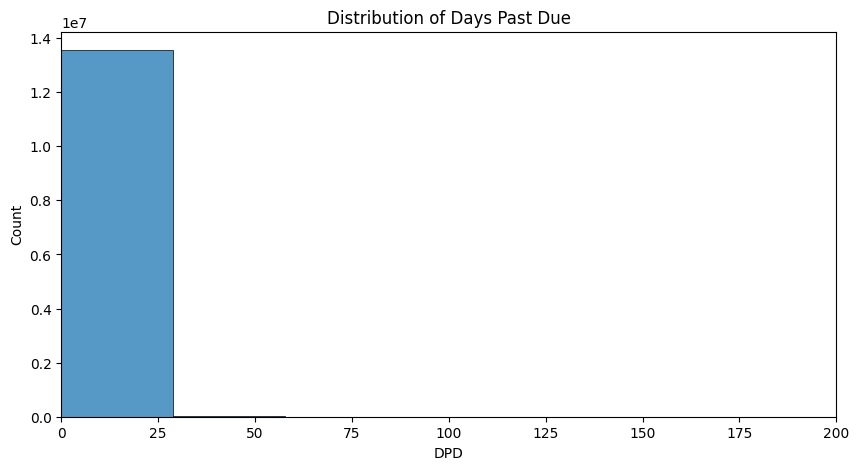

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    installments['DPD'],
    bins=100
)

plt.xlim(0,200)

plt.title("Distribution of Days Past Due")
plt.show()

- The DPD distribution is heavily concentrated near 0, indicating that the majority of customers make payments on time or with very small delays.

- The distribution is highly right-skewed, with a relatively small number of customers showing large delinquency values, representing high-risk default-prone borrowers.

In [10]:
def dpd_bucket(x):

    if x == 0:
        return "Current"

    elif x <= 30:
        return "1-30"

    elif x <= 60:
        return "31-60"

    elif x <= 90:
        return "61-90"

    else:
        return "90+"

In [11]:
installments['DPD_BUCKET'] = (
    installments['DPD']
    .apply(dpd_bucket)
)

In [12]:
installments['DPD_BUCKET'].value_counts(
    normalize=True
)

DPD_BUCKET
Current    0.915506
1-30       0.081440
31-60      0.001652
90+        0.001150
61-90      0.000252
Name: proportion, dtype: float64

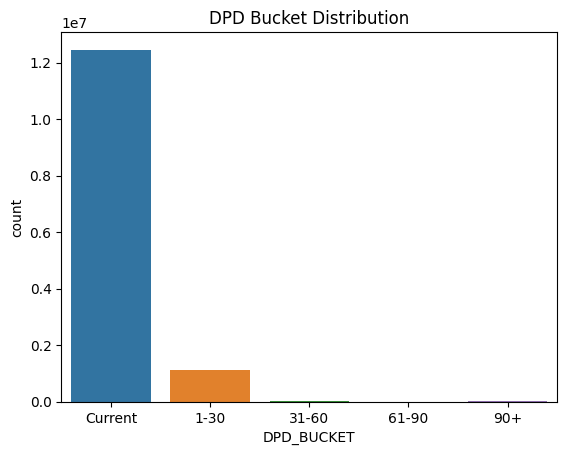

In [13]:
sns.countplot(
    x='DPD_BUCKET',
    data=installments,
    order=[
        'Current',
        '1-30',
        '31-60',
        '61-90',
        '90+'
    ]
)

plt.title("DPD Bucket Distribution")
plt.show()

- The majority of customers fall under the `Current` bucket, indicating that most borrowers are making payments on time with no significant delinquency.

- The number of customers decreases sharply as DPD severity increases, suggesting that severe delinquency (`60+ DPD`) is relatively rare but represents a high-risk segment suitable for bad customer definition.

In [14]:
installments['MOB'] = abs(
    installments['DAYS_INSTALMENT']
) // 30

In [15]:
customer_dpd = (
    installments
    .groupby('SK_ID_CURR')['DPD']
    .max()
    .reset_index()
)

customer_dpd.head()

,SK_ID_CURR,DPD
0,100001,11.0
1,100002,0.0
2,100003,0.0
3,100004,0.0
4,100005,1.0


In [16]:
customer_dpd['BAD_30'] = (
    customer_dpd['DPD'] >= 30
).astype(int)

In [17]:
customer_dpd['BAD_60'] = (
    customer_dpd['DPD'] >= 60
).astype(int)

In [18]:
customer_dpd['BAD_90'] = (
    customer_dpd['DPD'] >= 90
).astype(int)

In [19]:
for col in ['BAD_30', 'BAD_60', 'BAD_90']:

    print("="*40)
    print(col)

    print(
        customer_dpd[col]
        .mean()
    )

BAD_30
0.0698112707494692
BAD_60
0.029126556670308345
BAD_90
0.023734713048497145


In [20]:
vintage = (
    installments
    .groupby(
        ['SK_ID_CURR', 'MOB']
    )['DPD']
    .max()
    .reset_index()
)

In [21]:
vintage['BAD_FLAG'] = (
    vintage['DPD'] >= 60
).astype(int)

In [22]:
vintage_curve = (
    vintage
    .groupby('MOB')['BAD_FLAG']
    .mean()
    .reset_index()
)

vintage_curve.head()

,MOB,BAD_FLAG
0,0.0,0.000000
1,1.0,0.000000
2,2.0,0.000157
3,3.0,0.000273
4,4.0,0.000252


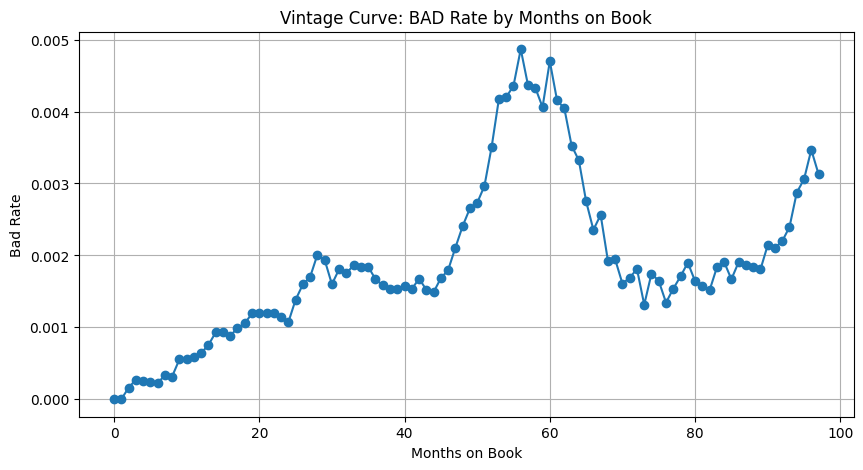

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    vintage_curve['MOB'],
    vintage_curve['BAD_FLAG'],
    marker='o'
)

plt.title("Vintage Curve: BAD Rate by Months on Book")

plt.xlabel("Months on Book")

plt.ylabel("Bad Rate")

plt.grid()

plt.show()

- The vintage curve shows that the bad rate gradually increases with Months on Book (MOB), indicating that delinquency risk rises as customers age in the portfolio.

- The bad rate peaks around the mid-tenure period (approximately MOB 55–60), suggesting that customers are more vulnerable to default during this repayment phase.

- After the peak period, the bad rate stabilizes and fluctuates within a narrower range, indicating relatively stable portfolio behavior in later months.

- The observed trend supports the use of a long-term performance window (such as 12 months or more) for defining bad customers in scorecard development.

### Roll Rate Analysis

In [24]:
installments = installments.sort_values(
    ['SK_ID_CURR', 'MOB']
)

In [25]:
installments['NEXT_BUCKET'] = (
    installments
    .groupby('SK_ID_CURR')['DPD_BUCKET']
    .shift(-1)
)

In [26]:
roll_rate = pd.crosstab(

    installments['DPD_BUCKET'],
    installments['NEXT_BUCKET'],
    normalize='index'
)

roll_rate

NEXT_BUCKET,1-30,31-60,61-90,90+,Current
DPD_BUCKET,,,,,
1-30,0.240003,0.010829,0.000889,0.002360,0.745919
31-60,0.369292,0.063476,0.033470,0.007963,0.525800
61-90,0.306045,0.057805,0.049589,0.103580,0.482981
90+,0.202669,0.014884,0.006031,0.258613,0.517803
Current,0.067301,0.000703,0.000116,0.000613,0.931267


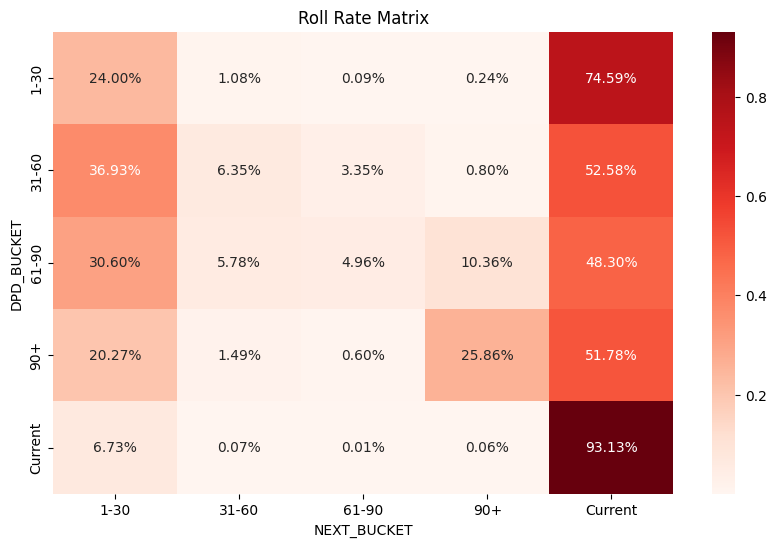

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    roll_rate,
    annot=True,
    fmt='.2%',
    cmap='Reds'
)

plt.title("Roll Rate Matrix")

plt.show()

### Final Target Definition

A customer is classified as BAD if:

- customer reaches 60+ DPD
- within 12 months performance window

Observation window includes all information available prior to loan booking.

This definition is supported through:
- vintage curve stabilization
- roll rate migration analysis
- balanced bad rate distribution

### Justification for Target Definition

- Although `90+ DPD` represents severe delinquency, it results in a relatively low bad rate and fewer default observations, which may lead to class imbalance and unstable scorecard estimation. 

- The roll rate analysis indicates that customers crossing the `60+ DPD` threshold exhibit significantly higher probability of migrating toward severe delinquency states, making `60+ DPD` an effective early indicator of default risk.

- Additionally, a 12-month performance window is preferred because most meaningful credit deterioration emerges within the early repayment period. Longer horizons may introduce macroeconomic noise and reduce the predictive relevance of application-level features.